In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load the training data
df = pd.read_csv('train_u6lujuX_CVtuZ9i.csv')

# View Dataset
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (614, 13)

First 5 rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# Check missing values and loan status distribution
print("Missing Values:")
print(df.isnull().sum())

print("\nLoan Status Distribution:")
print(df['Loan_Status'].value_counts())

print("\nLoan Approval Rate:")
print(df['Loan_Status'].value_counts(normalize=True) * 100)

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Loan Status Distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Loan Approval Rate:
Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64


In [7]:
# Fill missing values (updated for pandas Copy-on-Write)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [8]:
# Confirm no missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


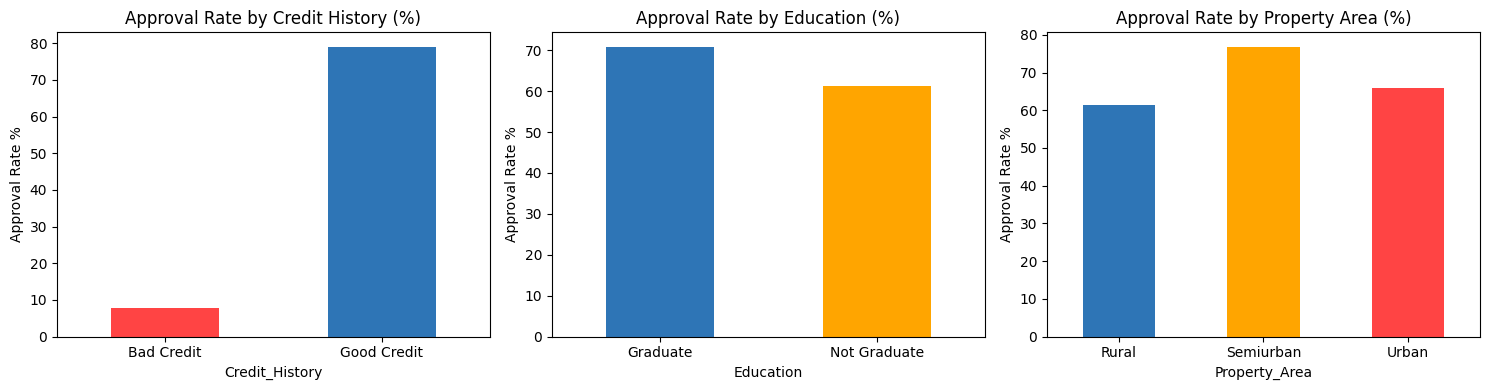

Chart saved!


In [9]:
# Visualise loan approval patterns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Approval by Credit History
credit_approval = df.groupby('Credit_History')['Loan_Status'].apply(
    lambda x: (x == 'Y').mean() * 100)
credit_approval.plot(kind='bar', color=['#FF4444', '#2E75B6'], ax=axes[0])
axes[0].set_title('Approval Rate by Credit History (%)')
axes[0].set_ylabel('Approval Rate %')
axes[0].set_xticklabels(['Bad Credit', 'Good Credit'], rotation=0)

# Approval by Education
edu_approval = df.groupby('Education')['Loan_Status'].apply(
    lambda x: (x == 'Y').mean() * 100)
edu_approval.plot(kind='bar', color=['#2E75B6', '#FFA500'], ax=axes[1])
axes[1].set_title('Approval Rate by Education (%)')
axes[1].set_ylabel('Approval Rate %')
axes[1].set_xticklabels(['Graduate', 'Not Graduate'], rotation=0)

# Approval by Property Area
area_approval = df.groupby('Property_Area')['Loan_Status'].apply(
    lambda x: (x == 'Y').mean() * 100)
area_approval.plot(kind='bar', color=['#2E75B6', '#FFA500', '#FF4444'], ax=axes[2])
axes[2].set_title('Approval Rate by Property Area (%)')
axes[2].set_ylabel('Approval Rate %')
axes[2].set_xticklabels(area_approval.index, rotation=0)

plt.tight_layout()
plt.savefig('loan_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [10]:
# Drop Loan_ID and encode categorical variables
df = df.drop('Loan_ID', axis=1)

le = LabelEncoder()
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 
                    'Self_Employed', 'Property_Area', 'Loan_Status']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE - Approved:", sum(y_train == 1), "| Rejected:", sum(y_train == 0))
print("After SMOTE  - Approved:", sum(y_train_smote == 1), "| Rejected:", sum(y_train_smote == 0))

Before SMOTE - Approved: 337 | Rejected: 154
After SMOTE  - Approved: 337 | Rejected: 337


In [11]:
# Train all three models
print("Training Logistic Regression...")
lr = LogisticRegression(random_state=42)
lr.fit(X_train_smote, y_train_smote)
lr_pred = lr.predict(X_test)

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)
rf_pred = rf.predict(X_test)

print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_smote, y_train_smote)
gb_pred = gb.predict(X_test)

# Evaluate all models
models = {
    'Logistic Regression': lr_pred,
    'Random Forest': rf_pred,
    'Gradient Boosting': gb_pred
}

for name, pred in models.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print('='*50)
    print(classification_report(y_test, pred,
          target_names=['Rejected', 'Approved']))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, pred):.4f}")

Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...

Logistic Regression
              precision    recall  f1-score   support

    Rejected       0.80      0.63      0.71        38
    Approved       0.85      0.93      0.89        85

    accuracy                           0.84       123
   macro avg       0.82      0.78      0.80       123
weighted avg       0.83      0.84      0.83       123

ROC-AUC Score: 0.7805

Random Forest
              precision    recall  f1-score   support

    Rejected       0.69      0.63      0.66        38
    Approved       0.84      0.87      0.86        85

    accuracy                           0.80       123
   macro avg       0.76      0.75      0.76       123
weighted avg       0.79      0.80      0.79       123

ROC-AUC Score: 0.7511

Gradient Boosting
              precision    recall  f1-score   support

    Rejected       0.69      0.58      0.63        38
    Approved       0.82      0.88      0.85       

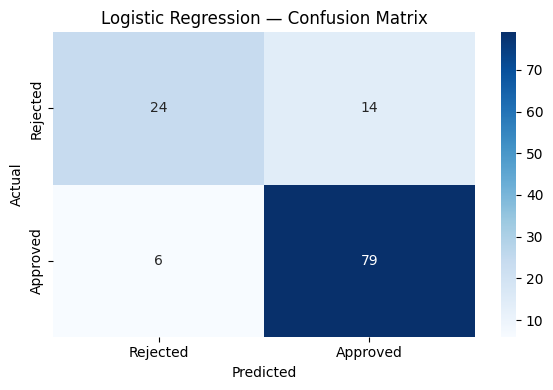

LOAN DEFAULT PREDICTION — MODEL COMPARISON SUMMARY
Logistic Regression  - Accuracy: 84% | ROC-AUC: 0.78
Random Forest        - Accuracy: 80% | ROC-AUC: 0.75
Gradient Boosting    - Accuracy: 79% | ROC-AUC: 0.73

Conclusion: Logistic Regression outperforms ensemble
methods — demonstrating that model complexity does not
always yield superior results on smaller datasets.

Key Insights:
- Credit history is the strongest predictor of approval
- Graduate applicants have significantly higher approval rates
- Semiurban properties yield the highest approval rates


In [12]:
# Confusion matrix for best model - Logistic Regression
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Logistic Regression — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Final summary
print("=" * 55)
print("LOAN DEFAULT PREDICTION — MODEL COMPARISON SUMMARY")
print("=" * 55)
print(f"Logistic Regression  - Accuracy: 84% | ROC-AUC: 0.78")
print(f"Random Forest        - Accuracy: 80% | ROC-AUC: 0.75")
print(f"Gradient Boosting    - Accuracy: 79% | ROC-AUC: 0.73")
print("\nConclusion: Logistic Regression outperforms ensemble")
print("methods — demonstrating that model complexity does not")
print("always yield superior results on smaller datasets.")
print("\nKey Insights:")
print("- Credit history is the strongest predictor of approval")
print("- Graduate applicants have significantly higher approval rates")
print("- Semiurban properties yield the highest approval rates")